<a href="https://colab.research.google.com/github/Fortuno21/skills-introduction-to-github/blob/main/Portfolio_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pyfolio-reloaded

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 29.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 93.2 MB/s eta 0:00:00
  Created wheel for peewee: filename=peewee-3.17.3-py3-none-any.whl size=138489 sha256=2146b4dc9b81eae453caa916dc4468b11fdeb74e93aeeb10e773b0f15a795ec5
  Stored in directory: /root/.cache/pip/wheels/39/c7/dd/909d267742f7fbb941ff081dacd661f622a0b4eb38f667b84b
Successfully built peewee
  Attempting uninstall: peewee
    Found existing installation: peewee 4.0.6
    Uninstalling peewee-4.0.6:
      Successfully uninstalled peewee-4.0.6


In [2]:
import pyfolio as pf
import yfinance as yf
import pandas as pd

/usr/local/lib/python3.12/dist-packages/pyfolio/pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(


## BENCHMARK

In [3]:
bench = yf.Ticker('SPY').history('10y')
bench_returns = bench.Close.pct_change()
bench_returns = bench_returns.dropna()

## PORTFOLIO


In [4]:
tickers = ['NVDA', 'CRWD', '	GOLD', 'GS']
weights = pd.Series([0.5, 0.5, 0, 0], index = tickers)

In [5]:
prices = None

for t in tickers:
  h = yf.Ticker(t).history('10y')[['Close']].rename(columns = {'Close': t})
  prices = h if prices is None else prices.join(h, how = 'inner')

In [6]:
asset_ret = prices.pct_change().dropna()
returns = asset_ret.mul(weights).sum(axis=1)
returns, bench_returns = returns.align(bench_returns, join='inner')

In [7]:

returns

,0
Date,
2019-06-13 00:00:00-04:00,0.089459
2019-06-14 00:00:00-04:00,-0.037371
2019-06-17 00:00:00-04:00,0.046937
2019-06-18 00:00:00-04:00,0.073414
2019-06-19 00:00:00-04:00,0.005491
...,...
2026-06-08 00:00:00-04:00,-0.000483
2026-06-09 00:00:00-04:00,-0.011598
2026-06-10 00:00:00-04:00,-0.016482


**Asset Allignemnt**:
set previously the benchmark, benchmark is alligned with same time-frame of the portfolio

In [8]:
returns, bench_returns = returns.align(bench_returns, join='inner')

**Tear Sheet**: reasuming table about main indexes and charts on return and volatility

/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '69.006%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"
/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '51.914%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"
/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '65.34%' has dtype incompatible with float64, please explicitly cast to a compatible 

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,59.21,2021-11-09,2023-01-05,2023-08-31,473
1,43.98,2020-02-19,2020-03-16,2020-04-24,48
2,34.23,2024-06-18,2024-08-05,2024-11-12,106
3,30.59,2025-02-18,2025-04-04,2025-05-27,71
4,26.28,2019-08-19,2019-10-18,2020-02-10,126


/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:850: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  starting_value=is_cum_returns[-1],
/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:850: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  starting_value=is_cum_returns[-1],
/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:1391: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.swarmplot(
/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or 

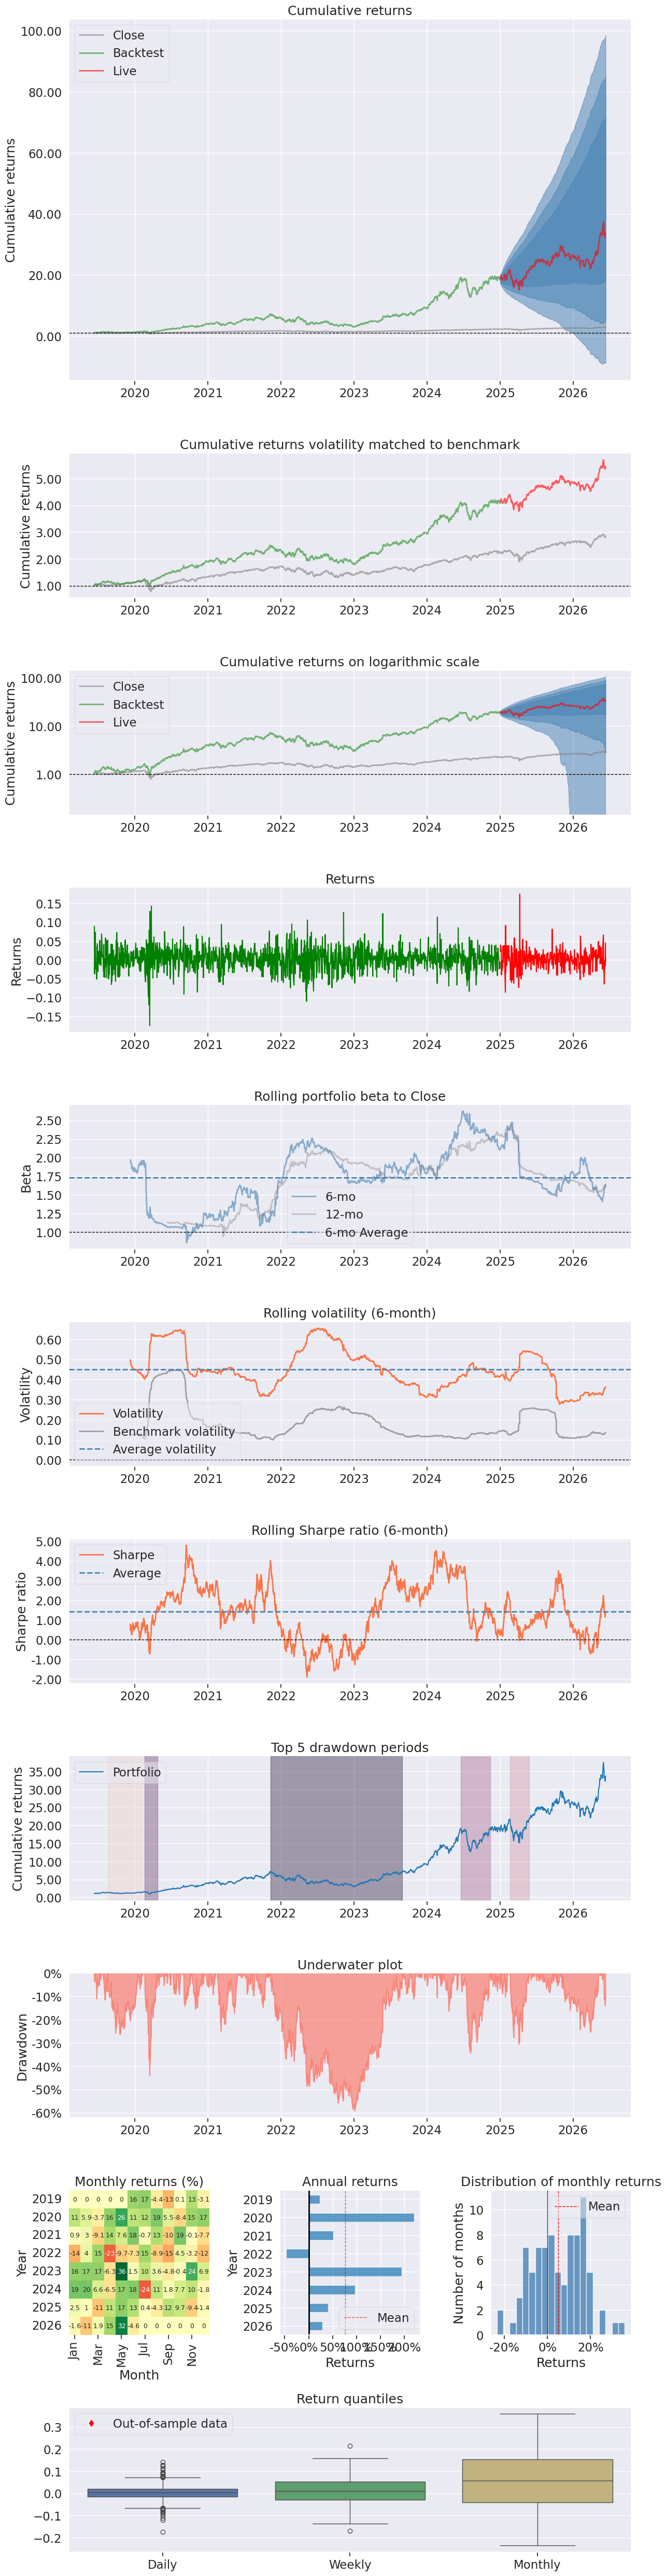

In [11]:
pf.create_returns_tear_sheet(returns, live_start_date='2025-01-01', benchmark_rets=bench_returns)

**Important event sheet**: for some economical impacting events is defined the portfolio performance

Stress Events,mean,min,max
Covid,0.24%,-17.49%,17.51%


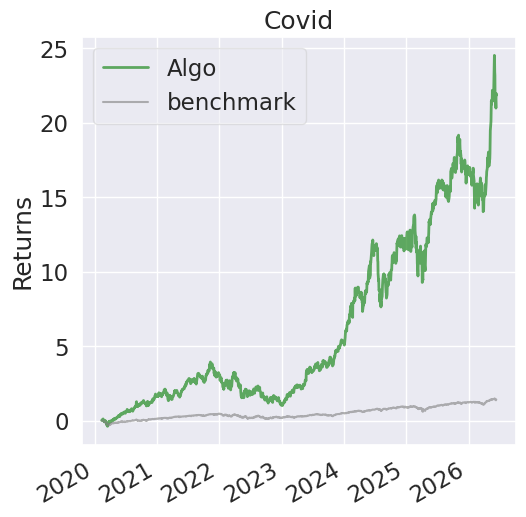

In [12]:
pf.create_interesting_times_tear_sheet(returns, benchmark_rets = bench_returns)